# MOSE Flood Barrier — 4x5 Optimization

This notebook is a worked example for a multi-objective optimization of the
**MOSE** mobile flood-barrier system that protects the Venice lagoon from
high tides. It shows how to:

- Define design variables and bounds
- Specify multiple objective functions and preference mappings
- Build constraints
- Run a Genetic Algorithm (GA) using two (potentially three) aggregation paradigms
- Visualize preference functions and optimization results

The structure follows the same approach as the artificial-reef worked example,
applied to the MOSE System of Interest identified in our stakeholder analysis.

## Problem

Venice sits on a shallow lagoon that connects to the Adriatic Sea through three
inlets: Lido, Malamocco and Chioggia. Because the city has both sunk and the
sea has risen over the last century, ordinary high tides ("acqua alta") now
regularly flood St Mark's Square and the historic centre, threatening a
UNESCO World Heritage city, its residents, and its tourism-based economy.

Several protection strategies were considered over the decades, including
raising quaysides, closing the lagoon permanently, and building fixed dams
across the inlets. A **mobile** barrier was ultimately chosen so that the
lagoon could stay open to the sea (and to shipping) under normal conditions,
and only be sealed off during a forecast high tide.

The resulting system, MOSE (*Modulo Sperimentale Elettromeccanico*), consists
of rows of large hollow steel flap-gates hinged to concrete foundations at
the seabed of the three inlets. In their resting state the gates lie filled
with water, flat on the seabed and invisible, allowing normal tidal exchange
and ship traffic. When a high tide is forecast, compressed air is pumped into
the gates, pushing the water out and rotating them upward until they break
the surface and temporarily wall off the lagoon from the sea. This design
keeps shipping routes usable, allows normal (low) tides to keep flushing the
lagoon, and still blocks the sea during a dangerous surge but, as our
stakeholder analysis showed, it also introduces technical, ecological and
political trade-offs that make it an interesting System of Interest to
optimize further.

## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully,
your environment must include the required dependencies (the `mude-base`
environment used in the artificial-reef example is sufficient).

In addition, several plotting settings are defined, and the local optimisation
code is imported. As with the reef example, the `genetic_algorithm_pfm`
package (provided as a course zip file) must be extracted in the same
directory as this notebook, since it is imported using a **relative import**.
Running this notebook outside that directory structure will raise
`ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`.

In [7]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize

# Define default plotting parameters
plt.rcParams['font.size'] = '10'
plt.rcParams['savefig.dpi'] = 300

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm

## Design Variables and Bounds

The MOSE system is parameterized using four continuous design variables:

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Height above mean water level (freeboard when raised) | m | Continuous |
| `x2` | Ship passage depth at the navigation channel | m | Continuous |
| `x3` | Amount of MOSE gates | - | Discrete |
| `x4` | Thickness of a MOSE unit | m | Continuous |
| `x5` | Length of a MOSE unit  | m | Continuous |

**Note:** As in the reef example, design variables are defined only by their
bounds — not by their physical meaning — when passed to the optimiser. Bounds
were chosen to bracket physically plausible designs around the real system.

`X_irl` contains an approximate real-world reference design based on the
existing MOSE installation (78 gates, ~4.5 m gate thickness, ~15 m navigable
depth at the Malamocco inlet used by large ships, and an estimated ~3 m
operational freeboard above mean water level), which is later used for
comparison against the optimised solutions.

In [8]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('x1', 'Height above mean water level', 'm'),
    ('x2', 'Ship passage depth',            'm'),
    ('x3', 'Amount of MOSE gates',          ''),
    ('x4', 'Thickness MOSE unit',           'm'),
    ('x5', 'Length MOSE unit',           'm')
)

# set bounds for all variables
b1 = [0.1, 10]      # x1
b2 = [10, 20]       # x2
b3 = [3, 200]       # x3
b4 = [1, 10]        # x4
b5 = [10, 50]       # x5
bounds = [b1, b2, b3, b4, b5]

X_irl = [3.0, 15.0, 78, 4.5, 20.0]  # IRL point for reference in plots
plot_irl = True  # Can be True or False, depending on whether you want to plot the IRL point or not

## Constraints

Constraints ensure that all solutions remain physically feasible. Two
constraints are considered for the MOSE model:

- `constraint_1` — **structural adequacy**: a gate's thickness must scale with
  its freeboard height so that it can resist wave and tidal loading without
  buckling (a minimum thickness-to-height ratio).
- `constraint_2` — **spatial feasibility**: the total footprint of the gate
  array (number of gates × thickness) cannot exceed the available width of
  the inlet channel.

As in the reef example, each constraint function must be expressed as

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

and should return only the value of $g(\mathbf{x})$ — the inequality type
(`'ineq'`) is specified separately when registering the constraint in `cons`.

In [9]:
def constraint_1(variables):
    """Minimum thickness-to-height ratio for structural stability(buckling):

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x4 = variables[:, 3]
    min_ratio = 0.3   # minimum thickness-to-height ratio [-]

    return min_ratio * x1 - x4   # < 0


def constraint_2(variables):
    """Maximum structural footprint across the inlet channel:

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x3 = variables[:, 2]
    x5 = variables[:, 4]
    max_footprint = 900   # maximum combined gate footprint across the inlet [m]

    return x3 * x5 - max_footprint   # < 0


cons = [['ineq', constraint_1], ['ineq', constraint_2]]

## Objective Functions

This model optimises five objectives, each representing a different
stakeholder identified in our stakeholder analysis. The table below
summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| Italian State / funder | Construction & dredging cost | $ |
| City of Venice / residents | Flood protection level | % |
| Port Authority & shipping industry | Shipping capacity | ships/day |
| Lagoon scientists & NoMOSE / environmental groups | Lagoon water-exchange capacity | m³/yr |
| Tourism sector | Economic growth | $ |

Each objective is expressed as a function of the design variables. As in the
reef example, physical constants are introduced only to keep units
consistent — reasonable estimates are sufficient.

In [ ]:
# Define objective functions

def objective_function_1(x1, x2, x3, x4, x5):
    """
    Cost function.

    :return: float of construction & dredging cost in dollars.
    """
    cons1 = 2e5   # cost per gate, scaled by thickness and height, and total length
    cons2 = 1e6   # dredging cost factor for ship-passage depth

    return cons1 * x3 * x4 *(1 + 0.5 * x1) + cons2 * x2


def objective_function_2(x1, x2, x3, x4, x5):
    """
    Flood-protection function.

    :return: float of flood protection level in percent.
    """
    cons3 = 12     # sensitivity of protection to freeboard height
    cons4 = 0.05   # complexity/reliability penalty per gate away from optimum
    cons5 = 80     # optimal number of gates for reliable, redundant operation
    cons6 = 40     # baseline protection level

    return cons6 + cons3 * np.log1p(x1) - cons4 * np.abs(x3 - cons5)


def objective_function_3(x1, x2, x3, x4, x5):
    """
    Shipping-capacity function.

    :return: float of shipping capacity in ships per day.
    """
    cons7 = 5     # baseline shipping capacity
    cons8 = 0.9   # capacity gain per metre of passage depth
    cons9 = 0.05  # capacity loss per additional gate (complexity/closures)
    cons10 = 0.3  # capacity loss per metre of gate thickness (flow constriction)

    return cons7 + cons8 * x2 - cons9 * x3 - cons10 * x4


def objective_function_4(x1, x2, x3, x4, x5):
    """
    Lagoon water-exchange function.

    :return: float of net change in lagoon water-exchange capacity in m^3/year.
    """
    cons11 = 5e6   # water-exchange sensitivity scale
    cons12 = 100   # optimal number of gates for distributed, ecology-friendly flow control
    cons13 = 60    # spread of the optimum
    cons14 = 3e5   # water-exchange loss per metre of gate thickness (permanent seabed obstruction)

    return cons11 * np.exp(-((x3 - cons12) / cons13) ** 2) - cons14 * x4


def objective_function_5(x1, x2, x3, x4, x5):
    """
    Economic-growth function.

    :return: float of predicted economic growth in dollars.
    """
    cons15 = 3e6   # economic value of avoided flood damage & sustained tourism per protection point

    return cons15 * objective_function_2(x1, x2, x3, x4, x5)


# Define the list of objectives with their corresponding names, units and stakeholders
objectives = [
    (objective_function_1, "Cost",                   "$",            "Italian State"),
    (objective_function_2, "Flood Protection",       "%",            "City of Venice"),
    (objective_function_3, "Shipping Capacity",      "ships/day",    "Port Authority"),
    (objective_function_4, "Lagoon Water Exchange",  "m^3/year",     "Lagoon Scientists / NoMOSE"),
    (objective_function_5, "Economic Growth",        "$",            "Tourism Sector")
]


While developing the objective functions, it is helpful to investigate their
behaviour. Here the attainable minimum and maximum of each objective is
computed, exactly as in the reef example, using `scipy.optimize.minimize`
starting from the midpoint of the bounds. These ranges serve as a sanity
check and define the interval over which each objective is rated in the
preference functions.

In [11]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {}  # Dictionary to store the min and max values for each objective
midpoints = [np.mean(b) for b in bounds]

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1, f=obj_func: sign * f(*x)  # obj_func accepts a single array-like X

    min_val = minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x, f=obj_func: wrapped(x, sign=-1, f=f), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")


  Objective 1  :    min =    10,630,000.0  $               max = 2,420,000,000.0  $
  Objective 2  :    min =            35.1  %               max =            68.8  %
  Objective 3  :    min =             1.0  ships/day       max =            22.6  ships/day
  Objective 4  :    min =    -2,689,117.4  m^3/year        max =     4,700,000.0  m^3/year
  Objective 5  :    min =   105,431,166.5  $               max =   206,324,229.8  $


## Weights

When combining multiple objectives into a single score, each objective is
assigned a weight **$w_i$** reflecting its relative importance. All weights
must sum to one:

$$\sum_{i=1}^{5} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$ | Italian State | Cost |
| $w_2$ | City of Venice | Flood Protection |
| $w_3$ | Port Authority | Shipping Capacity |
| $w_4$ | Lagoon Scientists / NoMOSE | Lagoon Water Exchange |
| $w_5$ | Tourism Sector | Economic Growth |

`weights_before` initialises all weights equally ($w_i = 0.2$). `weights_after`
represents a plausible renegotiation following stakeholder pressure — in line
with the political and ecological flaws identified in our motivation —
shifting weight toward flood protection and lagoon health at the expense of
shipping and short-term economic growth.

In [12]:
# Weights per stakeholder — must sum to 1. Before negotiation all weights were set equal.
#                   cost   flood  ship  lagoon  econ
weights_before =    [0.20, 0.20, 0.20, 0.20, 0.20]
weights_after =     [0.15, 0.30, 0.10, 0.30, 0.15]

weights = weights_before  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using
a *preference curve*, exactly as in the reef example, built with
`pchip_interpolate`. For the MOSE model, four objectives are rated linearly:
more flood protection, shipping capacity and economic growth are always
better for their stakeholders, and lower cost is always better for the
Italian State.

The exception is lagoon water exchange (objective 4): too little exchange
risks stagnation and eutrophication, but the model also penalises very high
values that would require an impractically large or thick gate array — so
lagoon scientists and NoMOSE prefer an intermediate-to-high value rather than
the extreme maximum, directly reflecting the ecological flaw discussed in our
motivation.

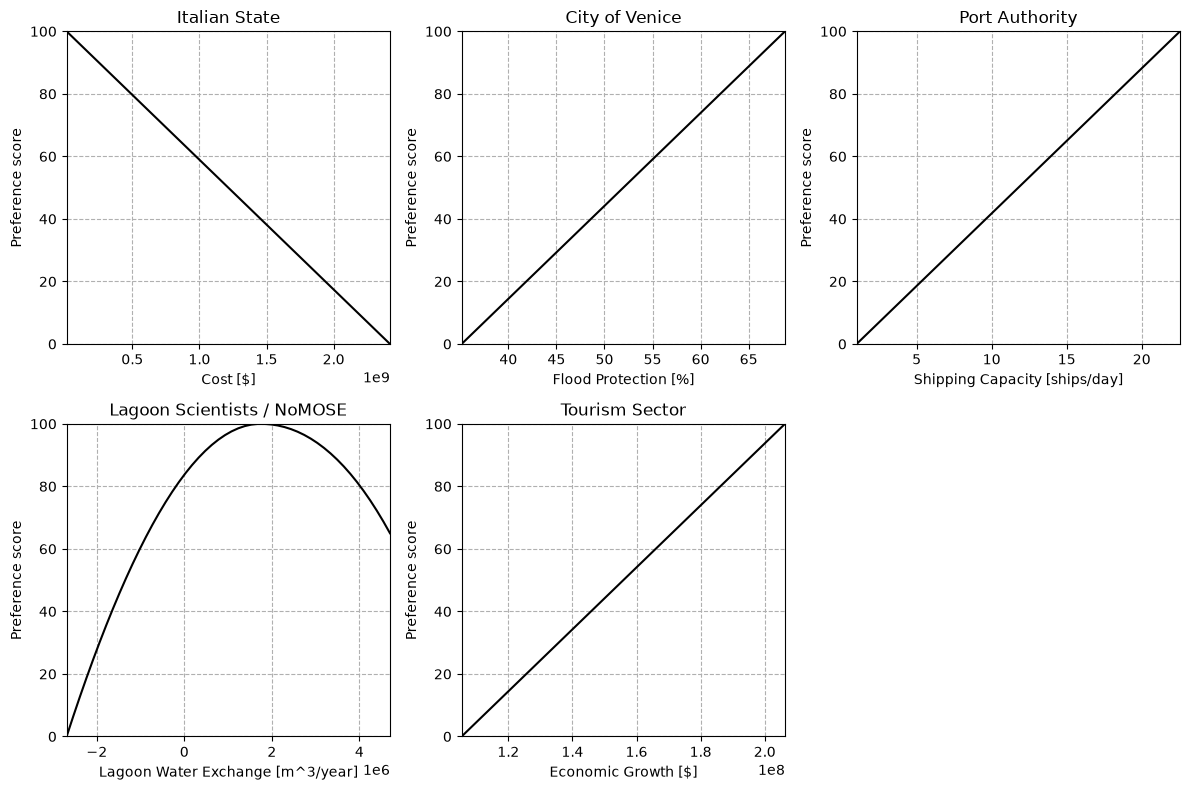

In [19]:
# Define preferences
lo4, hi4 = objective_minmax["Lagoon Water Exchange"]
mid4 = lo4 + 0.6 * (hi4 - lo4)

prefs_before = [[[objective_minmax["Cost"][0],              objective_minmax["Cost"][1]],              [100, 0]],    # preference cost
                [[objective_minmax["Flood Protection"][0],  objective_minmax["Flood Protection"][1]],  [0, 100]],    # preference flood protection
                [[objective_minmax["Shipping Capacity"][0], objective_minmax["Shipping Capacity"][1]], [0, 100]],    # preference shipping capacity
                [[lo4, mid4, hi4],                                                                      [0, 100, 65]], # preference lagoon water exchange
                [[objective_minmax["Economic Growth"][0],   objective_minmax["Economic Growth"][1]],   [0, 100]]]    # preference economic growth

pref_after = prefs_before  # placeholder: adjust curve shapes here if renegotiated preferences also change shape

prefs = prefs_before  # set to which preferences to use


# Preference curve values for plotting
# Generate objective value ranges
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives):
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

axes.flat[-1].set_visible(False)  # hide empty 6th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2, x3, x4, x5):
    cost = objective_function_1(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2, x3, x4, x5):
    flood = objective_function_2(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[1][0], prefs[1][1], flood)

def pref_func_3(x1, x2, x3, x4, x5):
    ship = objective_function_3(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[2][0], prefs[2][1], ship)

def pref_func_4(x1, x2, x3, x4, x5):
    lagoon = objective_function_4(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[3][0], prefs[3][1], lagoon)

def pref_func_5(x1, x2, x3, x4, x5):
    econ = objective_function_5(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[4][0], prefs[4][1], econ)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4, pref_func_5]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calls the separate preference functions declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4, x5)
    p_2 = pref_func_2(x1, x2, x3, x4, x5)
    p_3 = pref_func_3(x1, x2, x3, x4, x5)
    p_4 = pref_func_4(x1, x2, x3, x4, x5)
    p_5 = pref_func_5(x1, x2, x3, x4, x5)

    return weights, [p_1, p_2, p_3, p_4, p_5]

## Optimisation

Now that everything is in place, we can run the optimisation. As in the reef
example, this relies on `GeneticAlgorithm` from the `genetic_algorithm_pfm`
package (see `help(GeneticAlgorithm)` and `aggregations.md` in that package
for details on each aggregation paradigm). Because a genetic algorithm relies
on randomness, results are expected to vary slightly between runs.

**Note:** this cell requires the actual `genetic_algorithm_pfm` course
package to be present next to this notebook — it is not reimplemented here,
so run it in the same environment as the reef example.

The optimisation is run using the `'minmax'`, `'a-fine'` and (optionally)
`'tetra'` aggregation paradigms. After computing the optimal results, the
solutions are plotted on top of their corresponding preference curves,
alongside the approximate real-world (IRL) MOSE design for comparison.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            3.5693       467000001.3945   0            0.004        432         
1            2.3555       125000003.9168   0            0.06         115         
2            1.964        76000002.8477    0            0.132        68          
3            1.902        28000002.5202    0            0.176        27          
4            1.8724       22000002.2394    0            0.183        21          
5            1.8724       26000002.0923    1            0.188        25          
6            1.8724       21000002.1505    2            0.188        20          
7            1.8724       22000002.0537    3            0.189        21          
8            1.8724       23000002.0759    4            0.186        22          
9            1.8724       27000002.0276    5            0.187        26          
10           1.8724

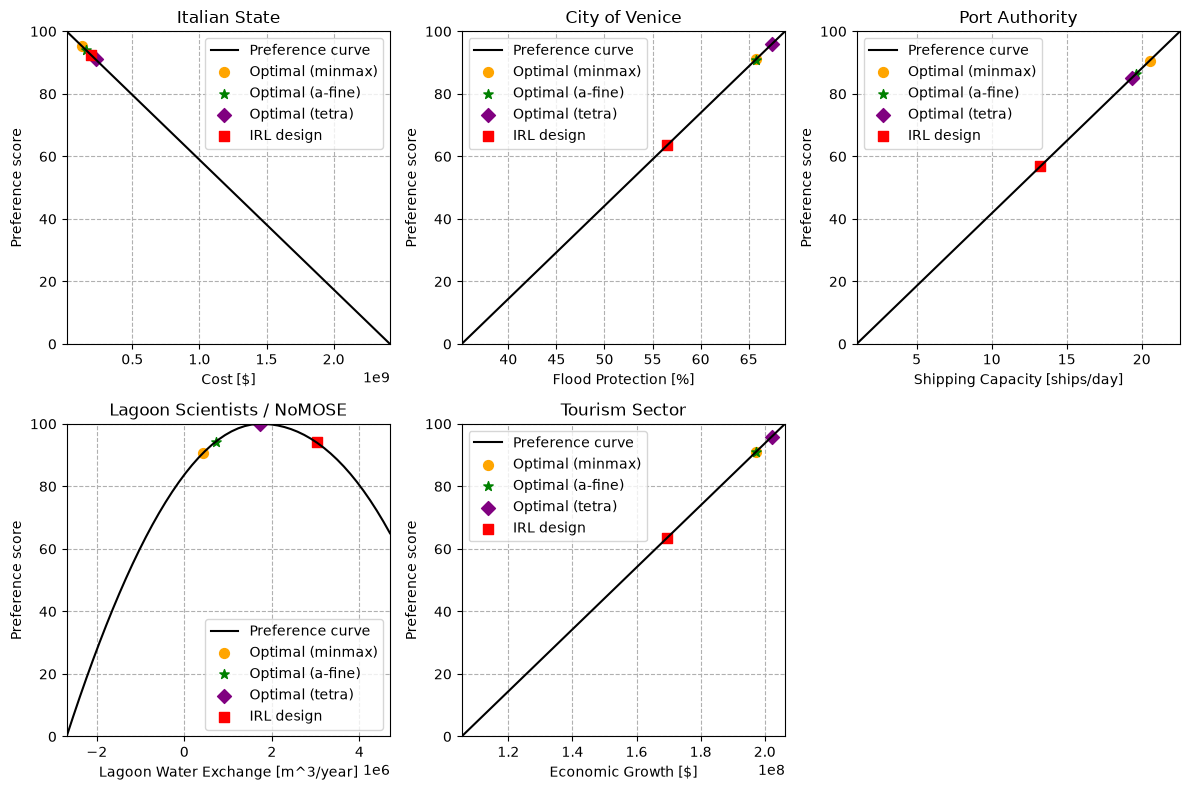

In [20]:
# We run the optimization with two (or three) paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*', 'D']
colours  = ['orange', 'green', 'purple']

# Define the figure and axes before the loop
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives):
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:')
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}')

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var)   # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var)  # Calculate resulting preference score

        # Print and plot the optimal point on the preference curve
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<28} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:5]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:5]:
    ax.legend(fontsize=10)

axes.flat[-1].set_visible(False)  # hide the sixth empty subplot

# Adjust the layout
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()